### **PhantomProof** 
#### Exploratory data Analysis

THis notebook performs a structured EDA on [`events_chaotic.csv`] (events_chaotic.csv) which is the output of the chaos injection engine.

The goal is to detect, quantify, and document every failure mode injected in [`03_chaos.ipynb`] notebook so that the silver layer cleaning logic can be written efficiently and accurately. 

EDA is organised into 5 sections which are the following:
1. Dataset overview and schema check.
2. Temporal anomalies 
3. Structural anomalies
4. Operational anomalies
5. Market and integrity anomalies




In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date

### for consistent plot style in the notebook:
sns.set_theme(style= "darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 4)

#  load chaotic events 
df = pd.read_csv(
    "events_chaotic.csv",
    parse_dates=["event_timestamp"]
)
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")



## load the chaotic events
## load dimension tables for joins
df_node = pd.read_csv("dim_node.csv")
df_product = pd.read_csv("dim_product.csv")
df_scanner = pd.read_csv("dim_scanner.csv")
df_baseline = pd.read_csv("events_baseline.csv", parse_dates = ["event_timestamp"])

print(f"chaotic events: {len(df):,}")
print(f"Baseline events: {len(df_baseline):,}")
print(f"Net delta: {len(df) - len(df_baseline):,} (+150 dupes injected, -169 removed by blackout/masking)")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['event_timestamp'].min()} to {df['event_timestamp'].max()}")


chaotic events: 436,124
Baseline events: 436,143
Net delta: -19 (+150 dupes injected, -169 removed by blackout/masking)
Columns: ['event_id', 'event_type', 'event_timestamp', 'node_id', 'device_id', 'product_id', 'units_sold', 'units_rto', 'units_transferred', 'source_node', 'destination_node', 'stock_on_hand', 'rto_reason', 'processing_lag_hours', 'session_id']
Date range: 2025-12-01 00:00:00 to 2026-08-12 22:57:00


#### **Section 1**
#### **Dataset Overview and Schema check**

In [ ]:
## dtypes
print("===Column datatypes===")
print(df.dtypes)
print()

## ---null profile
# units_sold is object was schema poisoning (contains strings like "9 units")
# processing_lag_hours is object after decimal separator chaos (eg: "1,23" instead of 1.23)
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_profile = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_profile = null_profile[null_profile["null_count"] > 0]. sort_values("null_count", ascending= False) # to filter and only get the columns with nulls 

print("=== Null Profile (columns with any nulls) ===")
print(null_profile.to_string())

## expected nulls are:
# rto_reason : None for non-RTO events (by design) +20 injected chaos nulls
# product_id : None for snapshot events (snapshots capture total stock, not per product)
# source_node: None for non_transfer events
# destantion_node : None for non transfer events


===Column datatypes===
event_id                        object
event_type                      object
event_timestamp         datetime64[ns]
node_id                         object
device_id                       object
product_id                      object
units_sold                      object
units_rto                        int64
units_transferred                int64
source_node                     object
destination_node                object
stock_on_hand                    int64
rto_reason                      object
processing_lag_hours            object
session_id                      object
dtype: object

=== Null Profile (columns with any nulls) ===
                  null_count  null_pct
rto_reason            424299     97.29
destination_node      364036     83.47
source_node           364036     83.47
product_id             81356     18.65
event_timestamp         2834      0.65


=== Event Type Distribution ===
event_type
customer_fulfillment    270835
snapshot                 81356
inbound_transfer         69537
rto_return               11845
lateral_transfer          2551



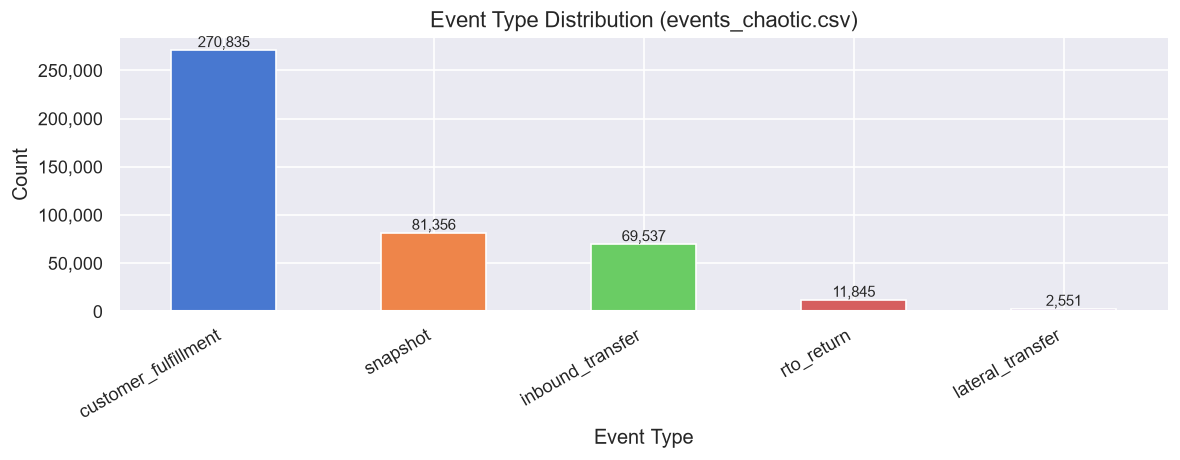

In [6]:
## event type counts
event_counts = df["event_type"].value_counts()
print("=== Event Type Distribution ===")
print(event_counts.to_string())
print()

fig, ax = plt.subplots(figsize = (10, 4))
event_counts.plot(kind="bar", ax= ax, color = sns.color_palette("muted", len(event_counts)))
ax.set_title("Event Type Distribution (events_chaotic.csv)", fontsize = 13)
ax.set_xlabel("Event Type")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}", 
                (bar.get_x() + bar.get_width() /2, bar.get_height()),
                ha= "center", va = "bottom", fontsize=9)
plt.xticks(rotation= 30, ha = "right")
plt.tight_layout()
plt.show()


In [7]:
# units_sold is object dtype, count how many rows are numeric
# chaos 2.1 injected "9 units" strings into 50 rows
# xhaos 4.3 injected 999999 (numeric but an extreme outlier)

units_numeric = pd.to_numeric(df["units_sold"], errors = "coerce")
non_numeric_mask = units_numeric.isna() & df["units_sold"].notna() # to ensure that only rows of type "9 units" are flagged

print(f"units_sold dtype: {df['units_sold'].dtype}")
print(f"Non numeric values: {non_numeric_mask.sum()}")
print(f"Sample non numeric values: {df.loc[non_numeric_mask, 'units_sold'].unique()[:10]}")

# Silver layer fix:
# df["units_sold"] = pd.to_numeric( df["units_sold"].astype(str).str.replace(" units", "", regex=False),
#   errors = "coerce")  

units_sold dtype: object
Non numeric values: 50
Sample non numeric values: ['2 units' '1 units' '10 units' '11 units' '7 units' '3 units' '4 units'
 '6 units' '5 units']


#### **Section 2**
#### **Temporal Anomalies**

Chaos modes injected:
- **[01] UTC/IST Drift**: 85,360 rows shifted -5h30m (dead RTC battery scanners)
- **[02] Timezone Double-Conversion**: 3,481 rows shifted +11h (old firmware v1.1.0)
- **[03] Batch Heartbeat**: 1,393 rows forced to 23:59:59 on 3 dates (slow scanners)
- **[04] Future Timestamp**: 4,318 rows pushed 2–45 days beyond SIM_END
- **[05] Midnight Rollover**: 10,795 rows time component zeroed (ERP export bug)
- **[06] Processing Lag Smear**: 2,597 rows with lag = 155.5 hours

In [8]:
SIM_END = pd.Timestamp("2026-06-30")
SIM_START = pd.Timestamp("2025-12-01")


# future timestamps (beyond SIM_END)
future_mask = df["event_timestamp"] > SIM_END
print(f"Future timestamps (beyond 2026-06-30) : {future_mask.sum():,}")
print(f"Max future timestamp: {df.loc[future_mask, 'event_timestamp'].max()}")
print()

# timestamps before SIM_START (UTC drift pulls some rows to NOv 2025)
before_sim_mask = df["event_timestamp"] < SIM_START
print(f"TImestamps before SIM_START (2025-12-01): {before_sim_mask.sum():,}")
print(f"Min timestamp in the dataset: {df['event_timestamp'].min()}")

### Silver layer fix:
# flag rows where event_timestamp < SIM_START — these are UTC drift candidates
# cross reference with dim_scanner where battery_backed_rtc == False
# fix: df.loc[utc_drift_mask, "event_timestamp"] += pd.Timedelta(hours=5, minutes=30)

Future timestamps (beyond 2026-06-30) : 536
Max future timestamp: 2026-08-12 22:57:00

TImestamps before SIM_START (2025-12-01): 0
Min timestamp in the dataset: 2025-12-01 00:00:00


AttributeError: module 'seaborn' has no attribute 'color_paette'

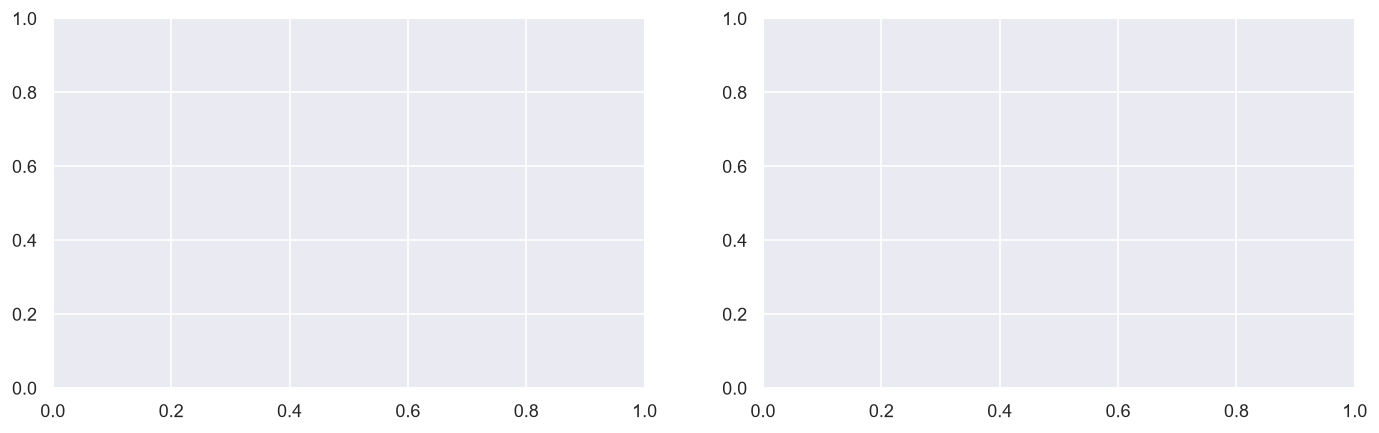

In [9]:
### hour-of-day distribution
# batch heartbeat should show a spike at hour 0
# midnight rollover should show a spike at hour 0
# normal darkstore snapshots: 6, 13, 18, 23

df["event_hour"] = df["event_timestamp"].dt.hour
fig, axes = plt.subplots(1,2, figsize= (14,4))

# left contains all events
df["event_hour"].value_counts().sort_index().plot(
    kind = bar, ax = axes[0], color = sns.color_paette("muted")[0]
)
axes[0].set_title("Fulfillment Events by hour of day", fontsize = 11)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# right contains fulfillment only (removes scheduled snapshot spikes)
df[df["event_type"] == "customer_fulfillment"]["event_hour"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color = sns.color_palette("muted")[2]
)
axes[1].set_title("Fulfillment events by hour of day", fontsize=11)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# hour 23 spike  = batch heartbeat + midnight rollover combined
# hour 0 spike = midnight rollover 
print(f"Hour 0 events: {(df['event_hour'] == 0).sum():,} (expected: midnight rollover ~10,795)")
print(f"Hour 23 events: {(df['event_hour'] == 23).sum():,} (expected: batch heartbeat spike)")

Unparseable lag values (comma decimal): 0
Extreme lag rows (>24h) : 4960
Lag smear rows (exactly 155.5 hours): 2,510


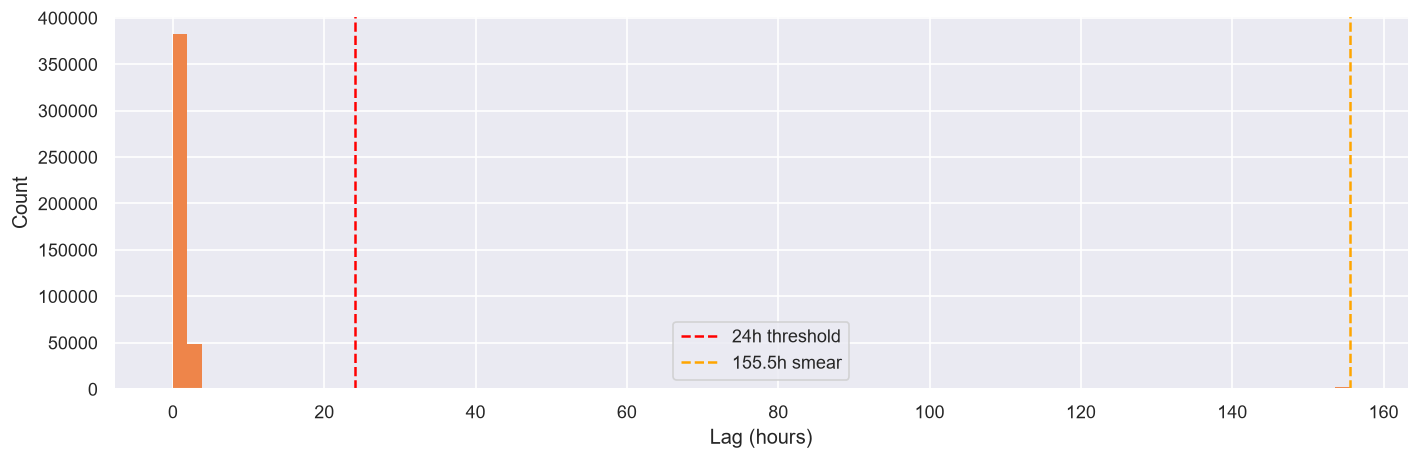

In [10]:
# processing_lag_hours anomalies
# chaos 2.2 injected comma decimal separators ("1,23") into ~895 rows
# chaos 1.6 injected 155.5 hours into ~2,597 rows
# chaos 5.1 injected 48-72 hour lags into ~2,408

# coerce to numeric, csv values become NaN
lag_numeric = pd.to_numeric(
    df["processing_lag_hours"].astype(str).str.replace(",",".", regex= False),
    errors = "coerce"
)

unparseable_lag = lag_numeric.isna().sum()
extreme_lag = (lag_numeric > 24).sum() # anything above 24h is anomalous
smear_lag = (lag_numeric == 155.5).sum()

print(f"Unparseable lag values (comma decimal): {unparseable_lag:,}")
print(f"Extreme lag rows (>24h) : {extreme_lag}")
print(f"Lag smear rows (exactly 155.5 hours): {smear_lag:,}")

fig, ax = plt.subplots(figsize = (12, 4))
lag_capped = lag_numeric.clip(upper = 200) # cap for readability
ax.hist(lag_capped.dropna(), bins = 80, color = sns.color_palette("muted")[1], edgecolor= "None")
ax.axvline(x= 24, color = "red", linestyle = "--", linewidth = 1.5, label = "24h threshold")
ax.axvline(x = 155.5, color = "orange", linestyle= "--", linewidth= 1.5, label = "155.5h smear")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# Silver layer fix:
# Step 1: df["processing_lag_hours"] = pd.to_numeric(
#     df["processing_lag_hours"].astype(str).str.replace(",", "."), errors="coerce"
# )
# Step 2: flag rows where lag > 24 as anomalous
# Step 3: rows where lag == 155.5 → cross-ref with degraded_scanners, impute median

### **Section 3**
### **Structural Anomalies**

Chaos modes:
- **[07] Schema Poisoning — Unit Suffix** — 50 rows: `units_sold` = "9 units" string
- **[08] Schema Poisoning — Decimal Separator** — 895 rows: `processing_lag_hours` = "1,23"
- **[09] Address/City Corruption** — 3 nodes: emoji/special chars in `city` field
- **[10] Null RTO Reason** — 20 rows: `units_rto > 0` but `rto_reason` is NULL
- **[11] UoM Mismatch** — 5 inbound transfer rows: quantity divided by 24 (cases vs units)